In [1]:
import pycolmap
print(pycolmap.__version__)
print(hasattr(pycolmap, 'estimate_and_refine_absolute_pose'))
print(hasattr(pycolmap, 'absolute_pose_estimation'))
print(hasattr(pycolmap, 'align_model'))

0.6.1
False
True
False


In [2]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook

tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import (
    extract_features,
    match_features,
    reconstruction,
    visualization,
    pairs_from_exhaustive,
)
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

# Setup
Here we define some output paths.

In [3]:
from pathlib import Path
from hloc import extract_features, match_features  # Assuming you have HLoc installed

# Set your Parallax image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Choose where to store the outputs
outputs = Path("outputs/superpoint+lightglue_4000p/")
sfm_pairs = outputs / "pairs-sfm.txt"
loc_pairs = outputs / "pairs-loc.txt"
sfm_dir = outputs / "sfm"
sfm_aligned_dir = outputs / "sfm_aligned"
features = outputs / "features.h5"
matches = outputs / "matches.h5"
camera_centers = Path("outputs/cam_centers.txt")

# (Optional) Clear the outputs folder
import shutil
shutil.rmtree(outputs, ignore_errors=True)
outputs.mkdir(parents=True, exist_ok=True)\

# Use LightGlue with DISK features
feature_conf = extract_features.confs["superpoint_parallax"]
matcher_conf = match_features.confs["superpoint+lightglue"]

fx, fy, cx, cy = 15400.0, 15400.0, 2000.0, 1500.0
width, height = 4000, 3000  # or the actual dimensions of your query image
camera = pycolmap.Camera(
    model='PINHOLE',
    width=width,
    height=height,
    params=[fx, fy, cx, cy]
)
print(camera)

Camera(camera_id=Invalid, model=PINHOLE, width=4000, height=3000, params=[15400.000000, 15400.000000, 2000.000000, 1500.000000] (fx, fy, cx, cy))


# 3D mapping
First we list the images used for mapping.

4 mapping images


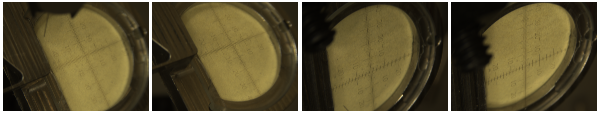

In [4]:
references = [p.relative_to(images).as_posix() for p in (images / "mapping/").iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

Then we extract features and match them across image pairs. Since we deal with few images, we simply match all pairs exhaustively. For larger scenes, we would use image retrieval, as demonstrated in the other notebooks.

In [5]:
extract_features.main(
    feature_conf, images, image_list=references, feature_path=features
)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/04/09 14:03:52 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 2048, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n1024-r4000',
 'preprocessing': {'grayscale': True, 'resize_max': 4000}}


Loaded SuperPoint model


c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\hloc\extractors\..\..\third_party\SuperGluePretrainedNetwork\models\superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any iss

  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/09 14:05:36 hloc INFO] Finished exporting features.
[2025/04/09 14:05:36 hloc INFO] Found 6 pairs.
[2025/04/09 14:05:36 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\venv\lib\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\venv\lib\site-packages\lightglue\lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


  0%|          | 0/6 [00:00<?, ?it/s]

[2025/04/09 14:05:42 hloc INFO] Finished exporting matches.


The we run incremental Structure-From-Motion and display the reconstructed 3D model.

In [6]:
fx, fy, cx, cy = 15400.0, 15400.0, 2000.0, 1500.0
opts = dict(
    camera_model='PINHOLE',
    camera_params=','.join(map(str, (fx, fy, cx, cy)))
)

mapper_options=dict(
    ba_refine_focal_length=False,
    ba_refine_extra_params=False
)

# ------------------------------------------------------------------
model = reconstruction.main(
    sfm_dir, images, sfm_pairs, features, matches, 
    image_list=references,
    image_options=opts,
    mapper_options = mapper_options
)
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(
    fig, model, color="rgba(255,0,0,0.5)", name="mapping", points_rgb=True
)
fig.show()

[2025/04/09 14:05:43 hloc INFO] Creating an empty database...
[2025/04/09 14:05:43 hloc INFO] Importing images into the database...
[2025/04/09 14:05:43 hloc INFO] Importing features into the database...


  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/09 14:05:43 hloc INFO] Importing matches into the database...


  0%|          | 0/6 [00:00<?, ?it/s]

[2025/04/09 14:05:43 hloc INFO] Performing geometric verification of the matches...
[2025/04/09 14:05:43 hloc INFO] Running 3D reconstruction...
[2025/04/09 14:05:44 hloc INFO] Reconstructed 1 model(s).
[2025/04/09 14:05:44 hloc INFO] Largest model is #0 with 4 images.
[2025/04/09 14:05:44 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_reg_images = 4
	num_cameras = 4
	num_points3D = 311
	num_observations = 1180
	mean_track_length = 3.79421
	mean_observations_per_image = 295
	mean_reprojection_error = 1.02129
	num_input_images = 4


We also visualize which keypoints were triangulated into the 3D model.

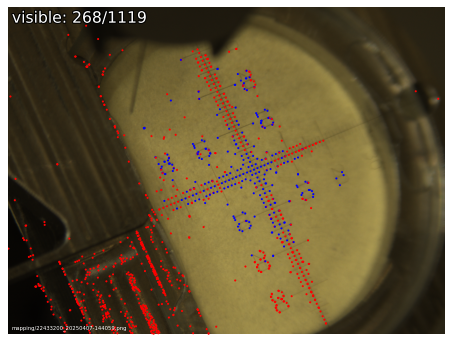

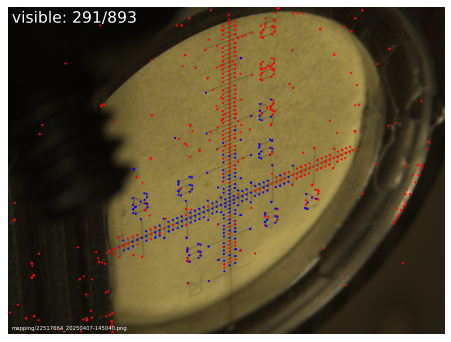

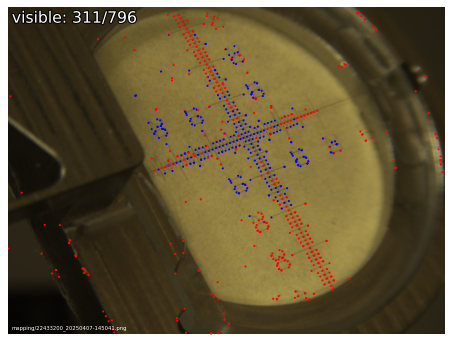

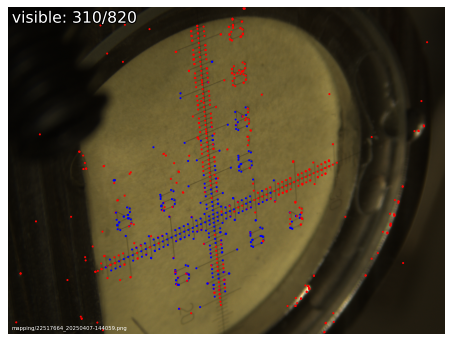

In [7]:
visualization.visualize_sfm_2d(model, images, color_by="visibility", n=5)

# Localization
Now that we have a 3D map of the scene, we can localize any image. To demonstrate this, we download [a night-time image from Wikimedia](https://commons.wikimedia.org/wiki/File:Paris_-_Basilique_du_Sacr%C3%A9_Coeur,_Montmartre_-_panoramio.jpg).

In [8]:
# List all files in the queries folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")
query_folder = images / "queries"
for file in query_folder.glob("*"):
    print(file.name)


Microscope_1_20250403-094514.png
Microscope_3_20250403-094514.png


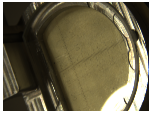

In [9]:
from hloc.utils.viz import plot_images
from pathlib import Path

# Define your base image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Define your query image path (relative to `images`)
query = "queries/Microscope_3_20250403-094514.png"
#query = "queries/Microscope_1_20250403-094514.png"


# Plot it
plot_images([read_image(images / query)], dpi=25)


Again, we extract features for the query and match them exhaustively.

In [10]:
extract_features.main(
    feature_conf, images, image_list=[query], feature_path=features, overwrite=True
)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references)
match_features.main(
    matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True
);

[2025/04/09 14:05:50 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 2048, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n1024-r4000',
 'preprocessing': {'grayscale': True, 'resize_max': 4000}}


Loaded SuperPoint model


c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\hloc\extractors\..\..\third_party\SuperGluePretrainedNetwork\models\superpoint.py:137: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any is

  0%|          | 0/1 [00:00<?, ?it/s]

[2025/04/09 14:06:09 hloc INFO] Finished exporting features.
[2025/04/09 14:06:09 hloc INFO] Found 4 pairs.
[2025/04/09 14:06:09 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}


  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/09 14:06:13 hloc INFO] Finished exporting matches.


In [11]:
print([img.name for img in model.images.values()])
# Check if each reference image is in the model
for r in references:
    img = model.find_image_with_name(r)
    if img is None:
        print(f"[ERROR] Image {r} not found in model")
    else:
        print(f"[OK] Found image {r} -> ID {img.image_id}")

['mapping/22433200_20250407-144059.png', 'mapping/22433200_20250407-145041.png', 'mapping/22517664_20250407-144059.png', 'mapping/22517664_20250407-145040.png']
[OK] Found image mapping/22433200_20250407-144059.png -> ID 1
[OK] Found image mapping/22433200_20250407-145041.png -> ID 2
[OK] Found image mapping/22517664_20250407-144059.png -> ID 3
[OK] Found image mapping/22517664_20250407-145040.png -> ID 4


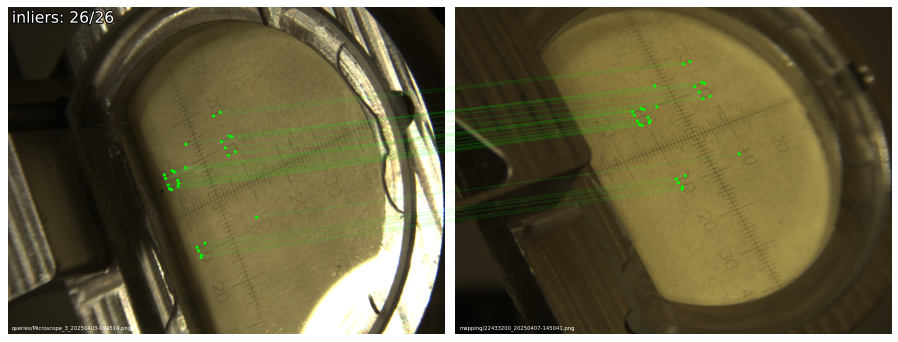

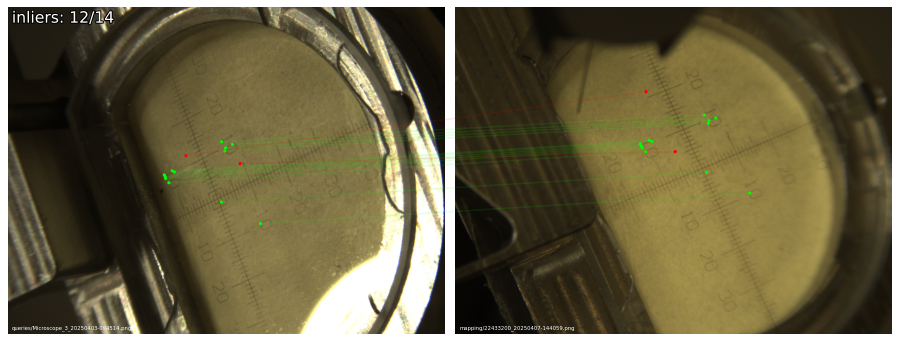

In [12]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster

#ref_ids = [model.find_image_with_name(r).image_id for r in references]
ref_ids = []
for r in references:
    img = model.find_image_with_name(r)
    if img is not None:
        ref_ids.append(img.image_id)
    else:
        print(f"[SKIPPED] {r} not in model.")


conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

#print(f'found {ret["num_inliers"]}/{len(ret["inliers"])} inlier correspondences.')
visualization.visualize_loc_from_log(images, query, log, model)

We visualize the correspondences between the query images a few mapping images. We can also visualize the estimated camera pose in the 3D map.

In [13]:
pose = pycolmap.Image(cam_from_world=ret["cam_from_world"])
viz_3d.plot_camera_colmap(
    fig, pose, camera, color="rgba(0,255,0,0.5)", name=query, fill=True
)
# visualize 2D-3D correspodences
inl_3d = np.array(
    [model.points3D[pid].xyz for pid in np.array(log["points3D_ids"])[ret["inliers"]]]
)
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()

In [20]:
from pathlib import Path

def write_points3D_to_ply(model, path):
    with open(path, 'w') as f:
        pts = list(model.points3D.values())
        f.write("ply\nformat ascii 1.0\nelement vertex {}\n".format(len(pts)))
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for pt in pts:
            x, y, z = pt.xyz
            r, g, b = pt.color
            f.write(f"{x:.6f} {y:.6f} {z:.6f} {r} {g} {b}\n")

# Usage
output_ply_path = Path("outputs/parallax-demo/sfm/points3D.ply")
write_points3D_to_ply(model, output_ply_path)
print(f"✅ Exported to {output_ply_path.resolve()}")


✅ Exported to C:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\outputs\parallax-demo\sfm\points3D.ply


Create the aligned model

In [16]:
import subprocess
import os
os.makedirs(sfm_aligned_dir, exist_ok=True)

colmap_cmd = [
    r"C:\Users\hanna.lee\Documents\00_Parallax\000_Project\colmap-x64-windows-cuda\COLMAP.bat", "model_aligner",
    "--input_path", str(sfm_dir),
    "--output_path", str(sfm_aligned_dir),
    "--ref_images_path", str(camera_centers),
    "--ref_is_gps", "0",
    "--alignment_type", "plane",
    "--alignment_max_error", "3.0"
]

result = subprocess.run(colmap_cmd, shell=True, capture_output=True, text=True)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return Code:", result.returncode)


STDOUT:
 
STDERR:
 I20250409 14:06:19.877967 28284 model.cc:135] 
Cartesian Alignment Coordinates extracted (MUST NOT BE GPS coords!).
I20250409 14:06:19.910022 28284 misc.cc:51] 
Aligning reconstruction to principal plane
------------------------------------------
I20250409 14:06:19.910206 28284 model.cc:425] => Alignment succeeded

Return Code: 0


In [17]:
# Export to PLY of the aligned model
aligned_model = pycolmap.Reconstruction(sfm_aligned_dir)
print(len(aligned_model.images))  # Should be > 0
write_points3D_to_ply(aligned_model, sfm_aligned_dir / "points3D.ply")


4


In [18]:

fig = viz_3d.init_figure()
# Plot all 3D points
all_pts3D = np.array([pt.xyz for pt in aligned_model.points3D.values()])
viz_3d.plot_points(fig, all_pts3D, color="white", ps=1, name="all points")

fig.show()


In [19]:
# Map image names in references to IDs in the aligned model
ref_ids = [aligned_model.find_image_with_name(r).image_id for r in references]

# Localization config
conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}

# Run localization
localizer = QueryLocalizer(aligned_model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

# Visualize
fig = viz_3d.init_figure()

# Draw the full aligned model
viz_3d.plot_reconstruction(fig, aligned_model, name="aligned_model", color="rgba(255,0,0,0.4)", points_rgb=True)

# Draw the localized query pose
pose = pycolmap.Image(cam_from_world=ret["cam_from_world"])
viz_3d.plot_camera_colmap(fig, pose, camera, color="rgba(0,255,0,0.5)", name=query, fill=True)

# Draw inlier 3D points
inlier_ids = np.array(log["points3D_ids"])[ret["inliers"]]
inlier_xyz = np.array([aligned_model.points3D[pid].xyz for pid in inlier_ids])
viz_3d.plot_points(fig, inlier_xyz, color="lime", ps=1, name=f"{query}_inliers")

fig.show()